In [1]:
import pandas as pd

In [7]:
synscape = pd.read_csv('No_dipplane90_1e66_9_24_fee_40_7_13_17_A_1strong1.txt', sep=' ')

In [8]:
print(synscape.shape)
synscape.head(10)

(9604, 14)


,x,y,z,ShearFailure,TensileFailure,FailureType,AmountRemoved,cohesion,friction,tension,strength_stress,diff_stress,model,group
0,74.8948,75.0039,-34.92710,58,0,1,1,1347140.0,27.2263,58869.1,1.14455,10113200.0,1347140.0,ZonesAtSurface
1,124.8090,75.0062,-9.90776,46,0,1,1,1112540.0,23.8851,119204.0,1.31403,4220560.0,1112540.0,ZonesAtSurface
2,174.7500,75.0010,-34.93590,45,0,1,2,715661.0,27.7186,68914.9,1.11951,8299090.0,715661.0,ZonesAtSurface
3,224.6810,75.0042,-9.92042,41,0,1,2,1433650.0,31.6439,86233.3,1.29713,6179860.0,1433650.0,ZonesAtSurface
4,274.6340,74.9966,-34.95620,25,0,1,3,655872.0,27.6517,140641.0,1.06035,10288500.0,655872.0,ZonesAtSurface
5,324.5710,74.9977,-9.95557,0,0,1,3,513129.0,37.5413,68755.4,1.02653,8280900.0,513129.0,ZonesAtSurface
6,374.5600,74.9929,-34.97740,0,0,1,4,1152940.0,31.8554,71646.5,1.77635,8217670.0,1152940.0,ZonesAtSurface
7,424.4390,74.9977,90.03080,3,0,1,2,1177550.0,44.4402,52715.6,2.04822,5687220.0,1177550.0,ZonesAtSurface
8,474.4230,74.9943,115.02100,0,0,1,2,1455850.0,40.7178,83840.3,2.64424,4919320.0,1455850.0,ZonesAtSurface
9,524.3930,74.9913,190.01000,0,0,1,1,1017780.0,30.8712,126246.0,2.06638,3213540.0,1017780.0,ZonesAtSurface


In [11]:
# check whether point spacing is regular
print(synscape['x'].nunique(), synscape['y'].nunique())
print(synscape['x'].diff().dropna().unique()[:5])
print(synscape['z'].diff().dropna().unique()[:5])

3124 9542
[49.9142 49.941  49.931  49.953  49.937 ]
[ 25.01934 -25.02814  25.01548 -25.03578  25.00063]


In [10]:
# check model and group as batch/run identifiers
print(synscape['model'].value_counts())
print(synscape['group'].value_counts())
print(synscape[['ShearFailure','TensileFailure', 'FailureType']].value_counts())

model
1300860.0    4
1129010.0    3
1247740.0    3
1408910.0    3
1029550.0    3
            ..
1126510.0    1
1417950.0    1
830397.0     1
1265930.0    1
998807.0     1
Name: count, Length: 9322, dtype: int64
group
ZonesAtSurface    9604
Name: count, dtype: int64
ShearFailure  TensileFailure  FailureType
0             0               0              2728
                              1               954
                              2               689
6             0               1               309
10            0               0               205
                                             ... 
42            15              1                 1
3             1               2                 1
                              0                 1
64            17              0                 1
70            20              0                 1
Name: count, Length: 454, dtype: int64


In [ ]:
# email confirms that these are from one simulation
# plot scatter

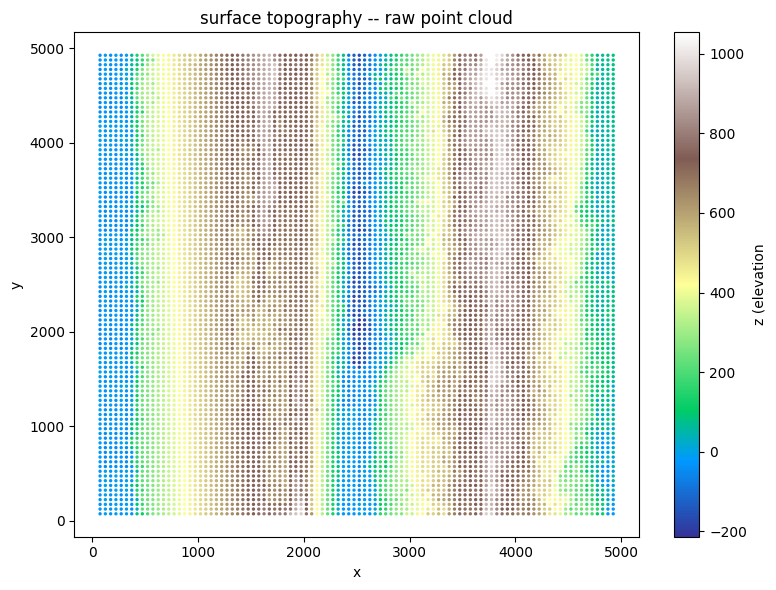

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
scatter = ax.scatter(synscape['x'],synscape['y'],c=synscape['z'],cmap='terrain',s=2)
plt.colorbar(scatter, ax=ax, label='z (elevation')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('surface topography -- raw point cloud')
plt.tight_layout()
plt.show()

In [16]:
print(synscape['x'].max())

4925.24


In [17]:
print(synscape['y'].max())

4925.07


In [19]:
# note that max values are just about the same
# likely a clean rectangular grid

import numpy as np

synscape_sorted = synscape.sort_values(['y','x'])
side = int(np.sqrt(len(synscape)))
print(side, side**2, len(synscape))

98 9604 9604


In [21]:
synscape_sorted.head(10)

,x,y,z,ShearFailure,TensileFailure,FailureType,AmountRemoved,cohesion,friction,tension,strength_stress,diff_stress,model,group
84,4275.39,74.9805,557.233,6,0,0,0,693707.0,42.0076,114914.0,1.93131,3199270.0,693707.0,ZonesAtSurface
83,4225.34,74.9806,597.184,0,0,0,0,1373050.0,34.8182,66122.4,2.30432,2815470.0,1373050.0,ZonesAtSurface
82,4175.29,74.9807,637.136,0,0,0,0,927536.0,41.3389,128328.0,2.32164,2541490.0,927536.0,ZonesAtSurface
25,1324.73,74.9815,639.567,0,0,0,0,1210240.0,27.9055,82685.0,3.38182,1582040.0,1210240.0,ZonesAtSurface
26,1374.77,74.9815,664.527,0,0,0,0,1083200.0,25.7860,78604.0,2.62235,1661780.0,1083200.0,ZonesAtSurface
24,1274.68,74.9817,614.606,0,0,0,0,856660.0,44.3091,133961.0,4.67484,1624420.0,856660.0,ZonesAtSurface
27,1424.81,74.9819,689.486,0,0,0,0,738237.0,36.1928,111451.0,2.75664,1679160.0,738237.0,ZonesAtSurface
23,1224.64,74.9821,589.644,0,0,0,0,1027990.0,30.3596,120018.0,3.08335,1650260.0,1027990.0,ZonesAtSurface
81,4125.23,74.9823,677.086,0,0,0,0,1332160.0,20.5000,63205.4,2.07603,2114010.0,1332160.0,ZonesAtSurface
22,1174.61,74.9825,564.682,0,0,0,0,1095440.0,16.2643,57737.4,2.07748,1681620.0,1095440.0,ZonesAtSurface


In [22]:
z_grid = synscape_sorted['z'].values.reshape(side,side)
print(z_grid.shape)

(98, 98)


In [23]:
# clean up grid for PCA and downstream

import numpy as np

x_grid = np.linspace(synscape['x'].min(), synscape['x'].max(), 98)
y_grid = np.linspace(synscape['y'].min(), synscape['y'].max(), 98)

from scipy.interpolate import griddata

xx, yy = np.meshgrid(x_grid, y_grid)
z_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['z'].values,
    xi=(xx,yy),
    method='cubic'
)

print(z_grid.shape)

(98, 98)


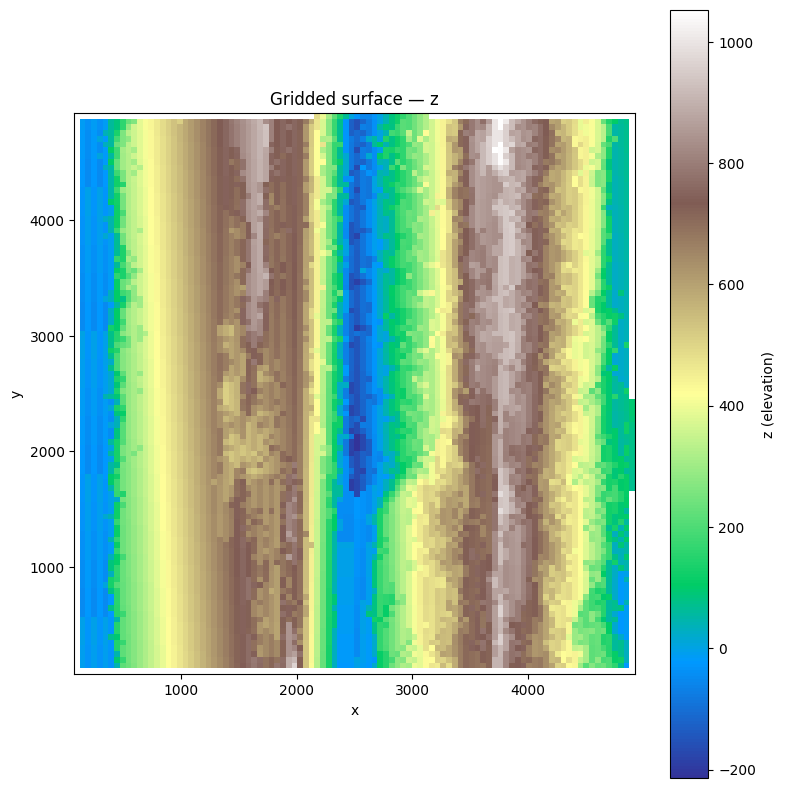

In [26]:
# plot z_grid as a check

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(z_grid, cmap='terrain', origin='lower',
               extent=[synscape['x'].min(), synscape['x'].max(), synscape['y'].min(), synscape['y'].max()])
plt.colorbar(im, ax=ax, label='z (elevation)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gridded surface — z')
plt.tight_layout()
plt.show()

In [27]:
from scipy.ndimage import sobel, generic_gradient_magnitude
import numpy as np

# grid resolution
res = (synscape['x'].max() - synscape['x'].min()) / 97

In [29]:
# first derivatives (gradients)
dz_dy = sobel(z_grid, axis=0) / (8 * res)
dz_dx = sobel(z_grid, axis=1) / (8 * res)

print('sobel grads calculated')

sobel grads calculated


In [37]:
# slope (degrees)
slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

print('slope calculated')
print(slope[:5,:5])

slope calculated
[[       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan 1.15751694 1.16190218 1.15638133]
 [       nan        nan 1.15958513 1.15734057 1.14793651]
 [       nan        nan 1.15667963 1.15701623 1.15354986]]


In [36]:
# aspect (degrees, 0=north, clockwise)

aspect = np.arctan2(-dz_dx, dz_dy) % 2*np.pi

sinasp = np.sin(aspect)
cosasp = np.cos(aspect)

print("aspect, sinasp, cosasp calculated")
print(sinasp[:5,:5])
print(cosasp[:5,:5])

aspect, sinasp, cosasp calculated
[[        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan  0.02088664  0.03392405  0.16550163]
 [        nan         nan -0.0002388   0.04987379  0.2014553 ]
 [        nan         nan -0.01750387  0.07349785  0.22474242]]
[[       nan        nan        nan        nan        nan]
 [       nan        nan        nan        nan        nan]
 [       nan        nan 0.99978185 0.99942441 0.98620952]
 [       nan        nan 0.99999997 0.99875553 0.97949771]
 [       nan        nan 0.9998468  0.99729538 0.97441821]]


In [39]:
# curvatures via second derivatives
d2z_dx2 = np.gradient(np.gradient(z_grid, axis=1), axis=1) / res**2
d2z_dy2 = np.gradient(np.gradient(z_grid, axis=0), axis=0) / res**2
d2z_dxdy = np.gradient(np.gradient(z_grid, axis=0), axis=1) / res**2

# profile curvature (in direction of slope)
# k_p = (fxxfx^2 + 2fxyfxfy + fyyfy^2) / ((fx^2 + fy^2)^(3/2))
prof_curv = -((dz_dx**2 * d2z_dx2) + (2*dz_dx*dz_dy*d2z_dxdy) + (dz_dy**2 * d2z_dy2)) / \
                ((dz_dx**2 + dz_dy**2)**1.5 + 1e-10)

plan_curv = (dz_dx**2 * d2z_dy2 - 2*dz_dx*dz_dy*d2z_dxdy + dz_dy**2 * d2z_dx2) / \
                ((dz_dx**2 + dz_dy**2)**1.5 + 1e-10)

print('profile and planar curvatures calculated')

profile and planar curvatures calculated


In [42]:
# sanity check
for name, arr in zip(['slope','aspect','sinasp','cosasp','prof_curv','plan_curv'],
                     [slope, aspect, sinasp, cosasp, prof_curv, plan_curv]):
    print(f"{name}: min={np.nanmin(arr):.5f}, max={np.nanmax(arr):.5f}, mean={np.nanmean(arr):.3f}")
    

slope: min=0.99927, max=75.46885, mean=36.269
aspect: min=0.00022, max=6.28312, mean=2.896
sinasp: min=-1.00000, max=1.00000, mean=0.131
cosasp: min=-1.00000, max=1.00000, mean=0.115
prof_curv: min=-0.75021, max=0.51235, mean=0.000
plan_curv: min=-0.88131, max=1.08740, mean=0.002


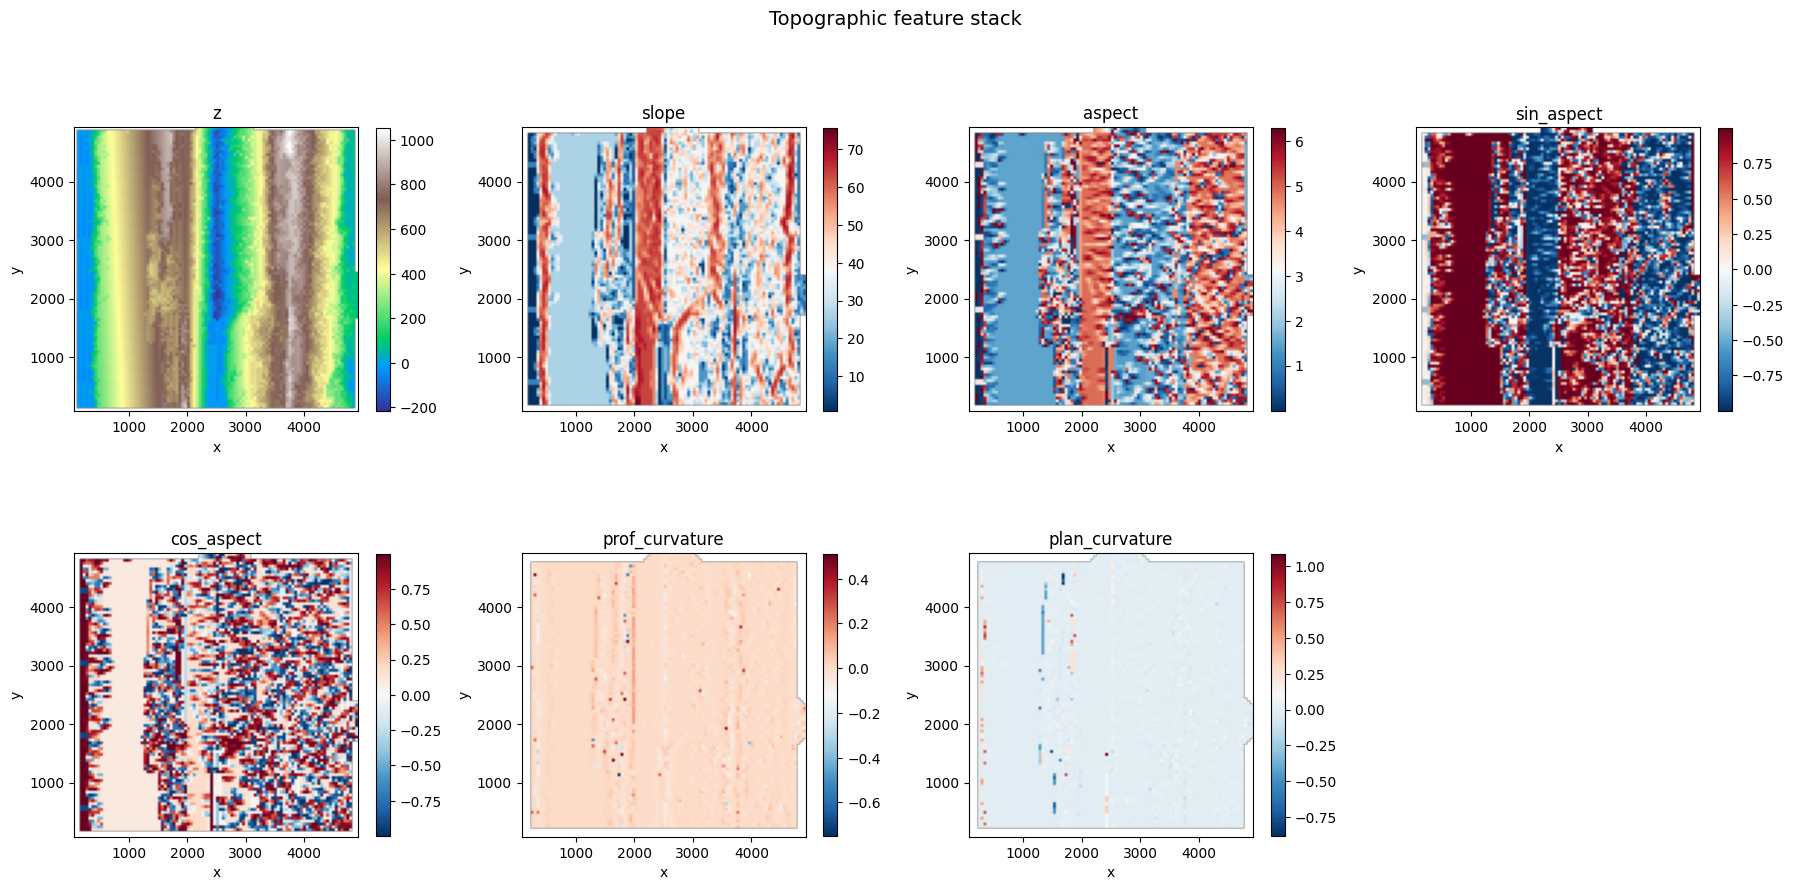

In [45]:
import matplotlib.pyplot as plt

features = {
    'z': z_grid,
    'slope': slope,
    'aspect': aspect,
    'sin_aspect': sinasp,
    'cos_aspect': cosasp,
    'prof_curvature': prof_curv,
    'plan_curvature': plan_curv
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, (name, arr) in enumerate(features.items()):
    im = axes[i].imshow(arr, cmap='terrain' if name == 'z' else 'RdBu_r',
                        origin='lower',
                        extent=[synscape['x'].min(), synscape['x'].max(),
                                synscape['y'].min(), synscape['y'].max()])
    plt.colorbar(im, ax=axes[i], shrink=0.7)
    axes[i].set_title(name)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

# hide the empty 8th panel
axes[-1].set_visible(False)

plt.suptitle('Topographic feature stack', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

profile_curvature: 2nd pct=-0.0496, 98th pct=0.0513
plan_curvature: 2nd pct=-0.0417, 98th pct=0.0589


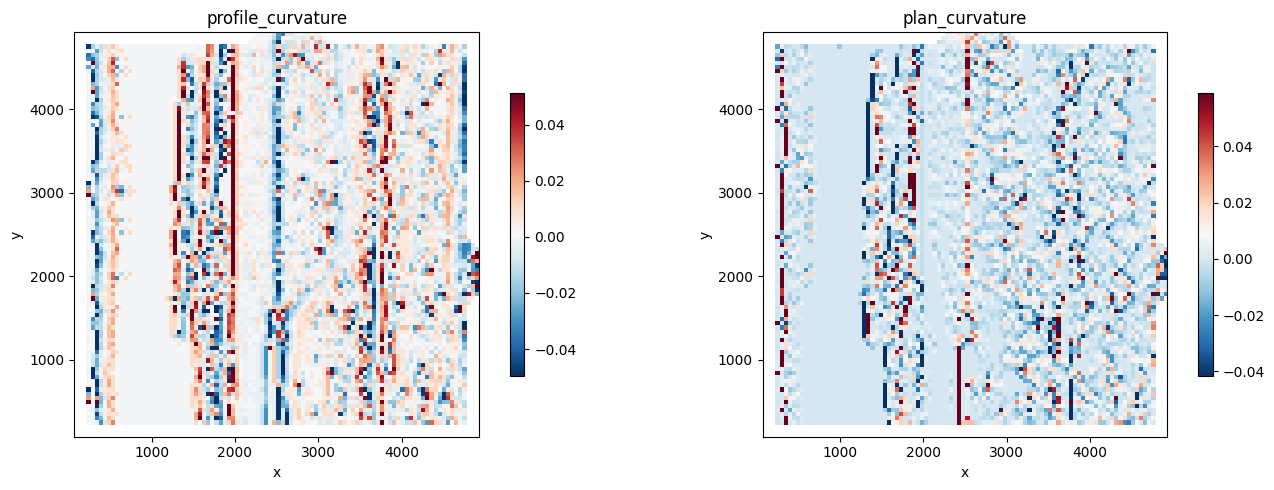

In [51]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, arr, name in zip(axes,
                         [prof_curv, plan_curv],
                         ['profile_curvature', 'plan_curvature']):
    vmin, vmax = np.nanpercentile(arr, [2, 98])
    print(f"{name}: 2nd pct={vmin:.4f}, 98th pct={vmax:.4f}")
    im = ax.imshow(arr, cmap='RdBu_r', origin='lower',
                   vmin=vmin, vmax=vmax,
                   extent=[synscape['x'].min(), synscape['x'].max(),
                                synscape['y'].min(), synscape['y'].max()])
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

sin_aspect: 2nd pct=-0.9995, 98th pct=0.9987
cos_aspect: 2nd pct=-0.9871, 98th pct=0.9993


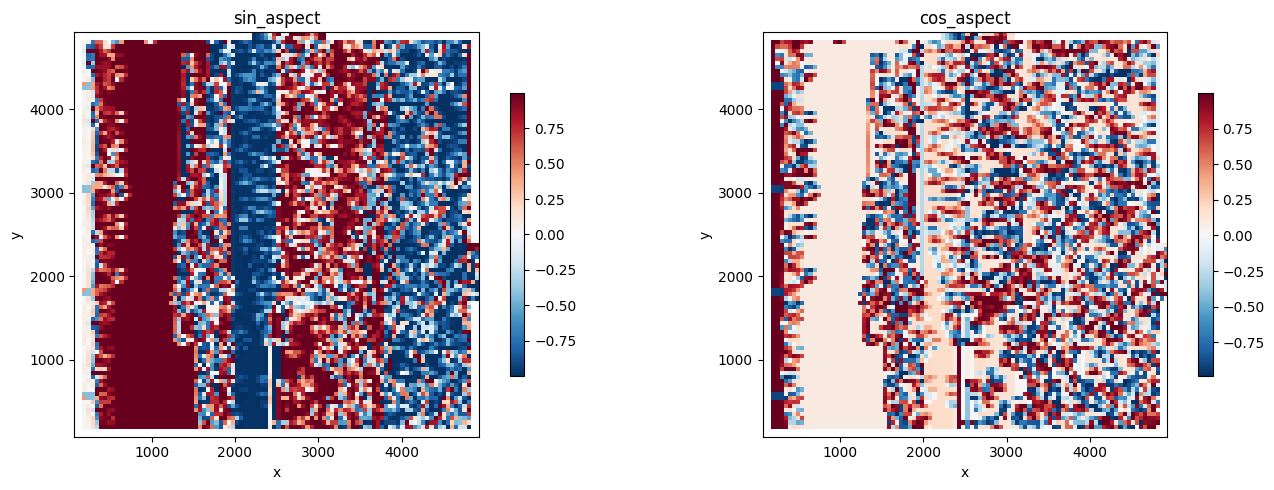

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, arr, name in zip(axes,
                         [sinasp, cosasp],
                         ['sin_aspect', 'cos_aspect']):
    vmin, vmax = np.nanpercentile(arr, [2, 98])
    print(f"{name}: 2nd pct={vmin:.4f}, 98th pct={vmax:.4f}")
    im = ax.imshow(arr, cmap='RdBu_r', origin='lower',
                   vmin=vmin, vmax=vmax,
                   extent=[synscape['x'].min(), synscape['x'].max(),
                                synscape['y'].min(), synscape['y'].max()])
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

In [55]:
# crop 2 pixels from all sides
crop = 3

z_c         = z_grid[crop:-crop, crop:-crop]
slope_c     = slope[crop:-crop, crop:-crop]
aspect_c    = aspect[crop:-crop, crop:-crop]
sinasp_c    = sinasp[crop:-crop, crop:-crop]
cosasp_c    = cosasp[crop:-crop, crop:-crop]
prof_curv_c = prof_curv[crop:-crop, crop:-crop]
plan_curv_c = plan_curv[crop:-crop, crop:-crop]

print(z_c.shape)

# verify no remaining NaNs
for name, arr in zip(['z','slope','sinasp','cosasp','prof_curv','plan_curv'],
                     [z_c, slope_c, sinasp_c, cosasp_c, prof_curv_c, plan_curv_c]):
    print(f"{name}: NaNs={np.isnan(arr).sum()}")

(92, 92)
z: NaNs=0
slope: NaNs=0
sinasp: NaNs=0
cosasp: NaNs=0
prof_curv: NaNs=0
plan_curv: NaNs=0


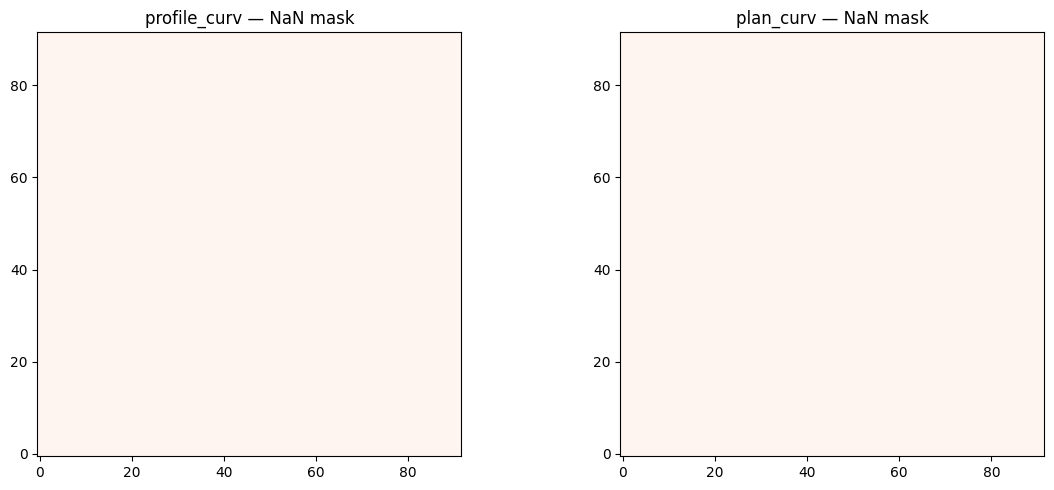

In [56]:
# find the renegade nans in the structure
# look at the NaN structure spatially
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, arr, name in zip(axes,
                         [prof_curv_c, plan_curv_c],
                         ['profile_curv', 'plan_curv']):
    ax.imshow(np.isnan(arr), origin='lower', cmap='Reds')
    ax.set_title(f"{name} — NaN mask")
plt.tight_layout()
plt.show()

In [57]:
# stack, standardize, PCA

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# stack features into (n_pixels, n_features)
feature_stack = np.stack([
    z_c, slope_c, sinasp_c, cosasp_c, prof_curv_c, plan_curv_c
], axis=-1)
print('features stacked')

features stacked


In [58]:
n_rows, n_cols, n_features = feature_stack.shape
X = feature_stack.reshape(-1, n_features)
print(f"feature matrix shape: {X.shape}")

feature matrix shape: (8464, 6)


In [59]:
# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('scaled')

scaled


In [60]:
# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print('pcaed')

pcaed


In [61]:
# explained variance
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.1f}%) -- cumulative: {pca.explained_variance_ratio_[:i+1].sum()*100:.1f}%")

PC1: 0.2444 (24.4%) -- cumulative: 24.4%
PC2: 0.2037 (20.4%) -- cumulative: 44.8%
PC3: 0.1677 (16.8%) -- cumulative: 61.6%
PC4: 0.1593 (15.9%) -- cumulative: 77.5%
PC5: 0.1214 (12.1%) -- cumulative: 89.6%
PC6: 0.1036 (10.4%) -- cumulative: 100.0%


In [62]:
# examine PCA loadings for correlation

import pandas as pd

feature_names = ['z', 'slope', 'sin_aspect', 'cos_aspect', 'prof_curv', 'plan_curv']

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(6)]
).round(3)

print(loadings)

              PC1    PC2    PC3    PC4    PC5    PC6
z           0.462 -0.100 -0.338  0.592  0.542  0.136
slope      -0.103  0.724  0.074 -0.286  0.484  0.378
sin_aspect  0.116 -0.642  0.264 -0.480  0.383  0.357
cos_aspect -0.162  0.012  0.844  0.490  0.141 -0.043
prof_curv   0.612  0.154  0.213  0.030 -0.527  0.527
plan_curv  -0.601 -0.170 -0.231  0.310 -0.167  0.657


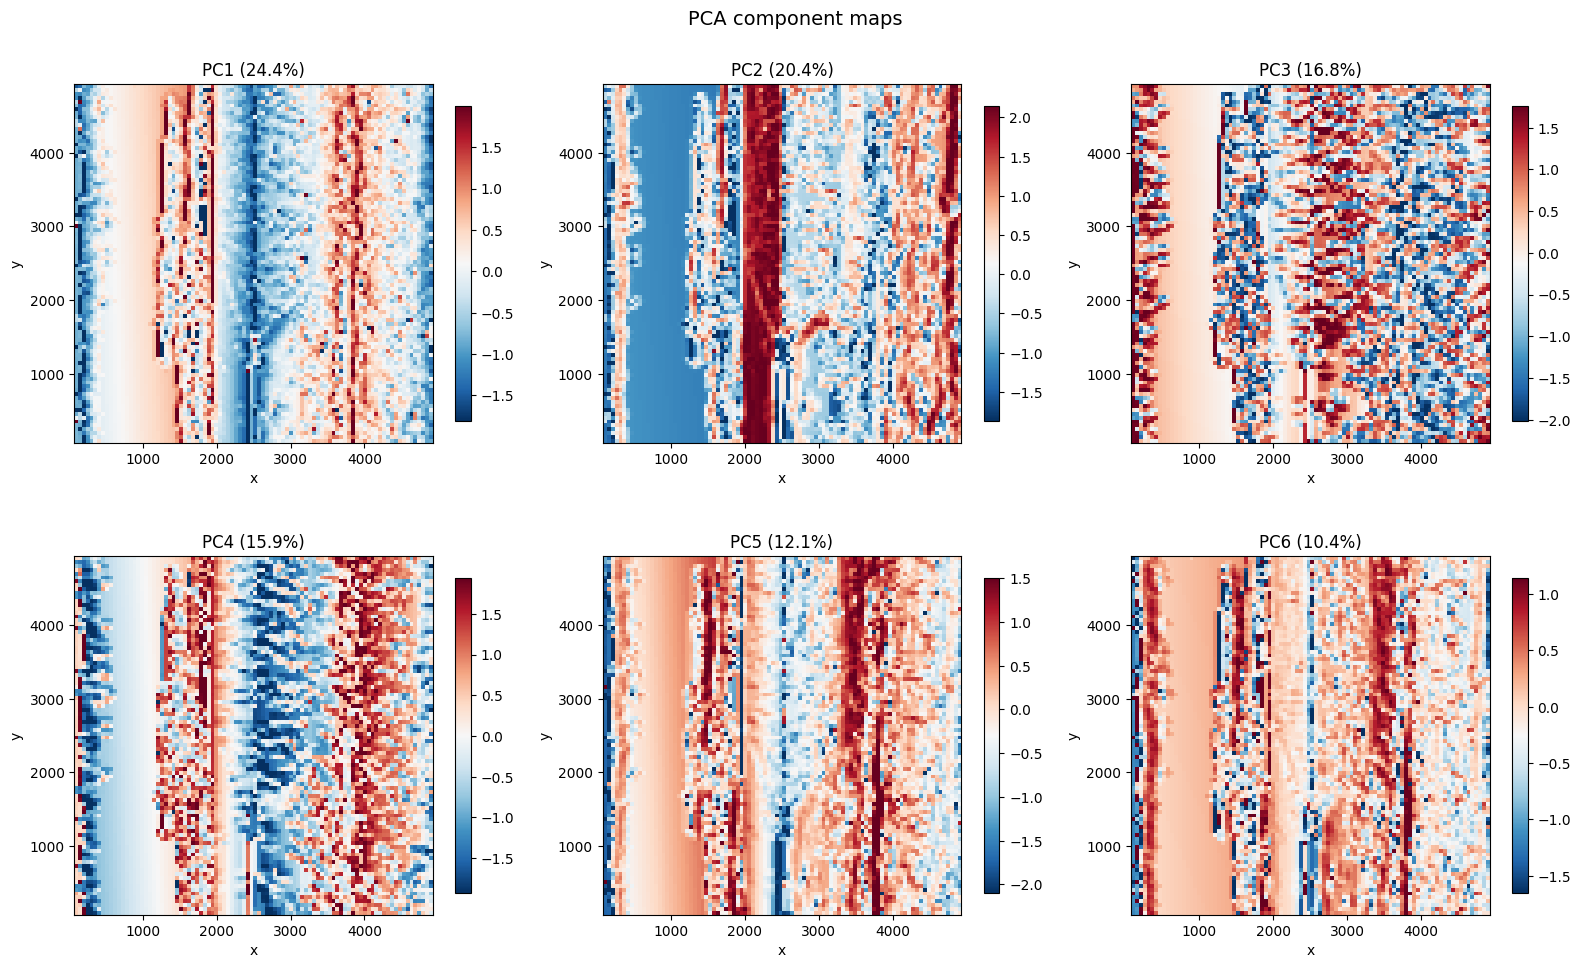

In [64]:
# reshape PC scores back to spatial grid
X_pca_grid = X_pca.reshape(n_rows, n_cols, 6)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i in range(6):
    arr = X_pca_grid[:, :, i]
    vmin, vmax = np.nanpercentile(arr, [2, 98])
    im = axes[i].imshow(arr, cmap='RdBu_r', origin='lower',
                        vmin=vmin, vmax=vmax,
                        extent=[synscape['x'].min(), synscape['x'].max(),
                                synscape['y'].min(), synscape['y'].max()])
    plt.colorbar(im, ax=axes[i], shrink=0.7)
    axes[i].set_title(f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')

plt.suptitle('PCA component maps', fontsize=14)
plt.tight_layout()
plt.show()